In [42]:
import joblib
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score, recall_score, precision_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
x_train_transformed= joblib.load('../data/x_train_transformed.pkl')
x_test_transformed= joblib.load('../data/x_test_transformed.pkl')
y_train= joblib.load('../data/y_train.pkl')
y_test= joblib.load('../data/y_test.pkl')
columntransformer= joblib.load('../models/preprocessor.pkl')
print(y_train.value_counts(normalize=True))
print(columntransformer)

returned
0    0.7725
1    0.2275
Name: proportion, dtype: float64
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['price_inr', 'rating_given', 'delivery_days',
                                  'discount_pct', 'customer_tenure_days',
                                  'num_previous_orders', 'num_previous_returns',
                                  'delivery_distance_km', 'is_weekend_order']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
      

In [26]:
#pipeline for logistic regression
logistic_reg = LogisticRegression(class_weight= "balanced", random_state= 42, max_iter= 1000)
logistic_reg.fit(x_train_transformed, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [34]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],  
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(logistic_reg, param_grid, scoring= 'roc_auc', cv=cv)
grid.fit(x_train_transformed, y_train)

c:\Users\harshitha\Projects\flipkart_capstone\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\harshitha\Projects\flipkart_capstone\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Use

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosi

In [37]:
y_pred = grid.predict(x_test_transformed)
y_proba = grid.predict_proba(x_test_transformed)
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred, pos_label=1),
    'recall': recall_score(y_test, y_pred, pos_label=1),
    'precision': precision_score(y_test, y_pred, pos_label=1),
    'roc_auc': roc_auc_score(y_test, y_proba[:, 1])}
print(metrics)
    

{'accuracy': 0.5925, 'f1_score': 0.3940520446096654, 'recall': 0.5824175824175825, 'precision': 0.29775280898876405, 'roc_auc': 0.6261997621220923}


In [51]:
#threshold_sweep
thresholds = np.arange(0.1, 0.9, 0.02)
results = []
for threshold in thresholds:
    y_pred_threshold = (y_proba[:, 1] >= threshold).astype(int)
    results.append({
        'threshold': round(threshold, 2),
        'f1_score': f1_score(y_test, y_pred_threshold, pos_label=1),
        'precision': precision_score(y_test, y_pred_threshold, pos_label=1, zero_division=0),
        'recall': recall_score(y_test, y_pred_threshold, pos_label=1)
    })
   
threshold_results = pd.DataFrame(results)


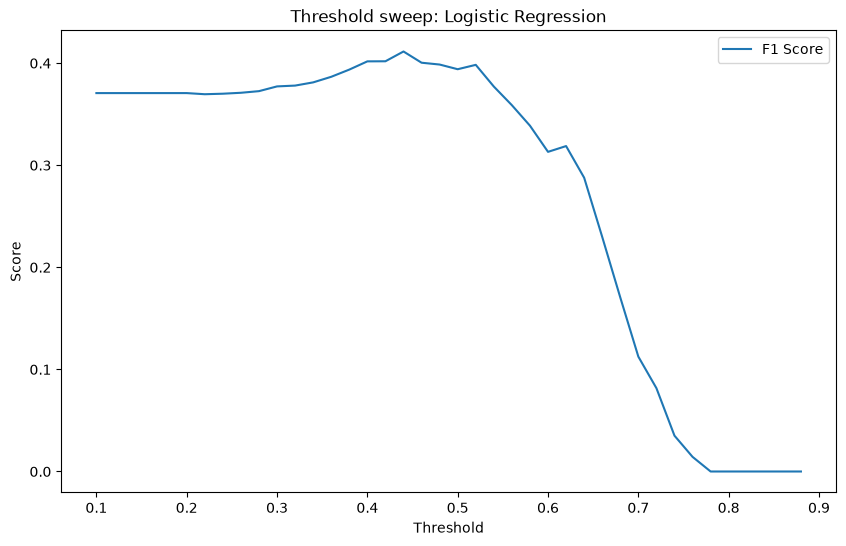

In [ ]:
#plotting the threshold sweep results for  f1 score
plt.figure(figsize=(10, 6))
plt.plot(threshold_results['threshold'], threshold_results['f1_score'], label='F1 Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold sweep: Logistic Regression')
plt.legend()
plt.show()

In [56]:
#report threshold maximises f1 score and its respective recall and precision
best_threshold_row = threshold_results.loc[threshold_results['f1_score'].idxmax()]
print(f"Best Threshold: {best_threshold_row['threshold']}")
print(f"Best F1 Score: {best_threshold_row['f1_score']}")
print(f"Best Precision: {best_threshold_row['precision']}")
print(f"Best Recall: {best_threshold_row['recall']}")

recall_gain_pp = (best_threshold_row['recall'] - metrics['recall']) * 100
precision_gain = (best_threshold_row['precision'] - metrics['precision']) * 100
f1_score_gain = (best_threshold_row['f1_score'] - metrics['f1_score']) * 100
print(f"Recall gain vs default (0.5) threshold: {recall_gain_pp:.1f} percentage points")
print(f"Precision gain vs default (0.5) threshold: {precision_gain:.1f} percentage points")
print(f"F1 score gain vs default (0.5) threshold: {f1_score_gain:.1f} percentage points")

Best Threshold: 0.44
Best F1 Score: 0.41141732283464566
Best Precision: 0.2812920592193809
Best Recall: 0.7655677655677655
Recall gain vs default (0.5) threshold: 18.3 percentage points
Precision gain vs default (0.5) threshold: -1.6 percentage points
F1 score gain vs default (0.5) threshold: 1.7 percentage points


Lowering the threshold from default 0.5 to 0.44 increased the recall rate by 18 % to 76%, which means now the model catches around 7 in 10 that are actually returned. The precision drop by 1.5%, where less than 3 in 10 are true returns, and most of the orders flaged as risky for returns are false alarm;. In this scenario False negatives(i.e,) missed returns are costly like refunds,transport and etc than false alarm, making recall more valuable than precision